<a href="https://colab.research.google.com/github/tallapragadaananya-a11y/ML-2-1-Skill1/blob/main/Week%205/Spotify_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
     Artist Name     Sex Country of Origin Primary Language Primary Genre  \
0          Drake    Male            Canada          English       Hip-Hop   
1   Taylor Swift  Female     United States          English           Pop   
2      Bad Bunny    Male     United States          Spanish     Reggaeton   
3     The Weeknd    Male            Canada          English           R&B   
4  Justin Bieber    Male            Canada          English           Pop   

   Artist Type  Debut Year  Total Streams (in millions)  \
0         Solo        2006                     137492.1   
1         Solo        2006                     127861.0   
2         Solo        2013                     125899.8   
3         Solo        2009                      95703.2   
4         Solo        2009                      78104.4   

   Lead Streams (in millions)  Feature Streams (in mi

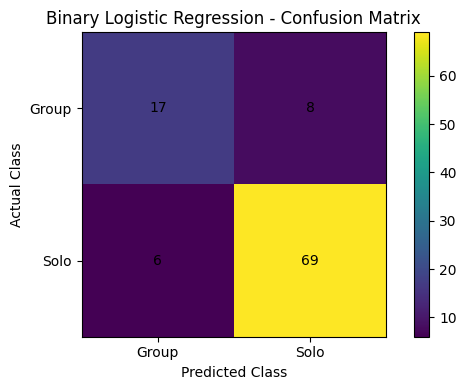


Saved plot -> spotify_logistic_confusion_matrix.png


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from google.colab import drive

# =========================================================
# 1. LOAD DATA
# =========================================================

drive.mount('/content/drive')

df = pd.read_csv(
    '/content/drive/MyDrive/Colab/Most Streamed Artists on Spotify.csv'
)

print(df.head())
print("\nDataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())


# =========================================================
# PART 1: BINARY LOGISTIC REGRESSION
# =========================================================

print("\nPART 1: BINARY LOGISTIC REGRESSION")
print("-" * 45)


# =========================================================
# 2. SELECT FEATURES AND TARGET
# =========================================================

# Numerical features
features = [
    "Debut Year",
    "% of Solo Streams",
    "% of Collaborative Streams"
]

X = df[features]

# Target
y = df[" Artist Type"] # Corrected column name to include leading space


# =========================================================
# 3. REMOVE MISSING VALUES
# =========================================================

data = pd.concat([X, y], axis=1).dropna()

X = data[features]
y = data[" Artist Type"] # Corrected column name to include leading space


print("\nArtist Type classes:")
print(y.value_counts())


# =========================================================
# 4. TRAIN / TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# =========================================================
# 5. TRAIN LOGISTIC REGRESSION MODEL
# =========================================================

binary_model = LogisticRegression(
    max_iter=1000
)

binary_model.fit(
    X_train,
    y_train
)


# =========================================================
# 6. PREDICTIONS
# =========================================================

y_pred = binary_model.predict(X_test)


# =========================================================
# 7. EVALUATION
# =========================================================

print("\nAccuracy:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred
    )
)


# =========================================================
# 8. PREDICT NEW ARTISTS
# =========================================================

new_artists = pd.DataFrame({
    "Debut Year": [2015, 2005, 1995],
    "% of Solo Streams": [90, 20, 10],
    "% of Collaborative Streams": [10, 80, 90]
})

predictions = binary_model.predict(new_artists)

probabilities = binary_model.predict_proba(new_artists)

classes = binary_model.classes_

print("\nPredictions for new artists:")

for i, prediction in enumerate(predictions):

    print(
        f"Artist {i+1}: "
        f"Predicted Artist Type = {prediction}"
    )

    print(
        "Probabilities:",
        dict(
            zip(
                classes,
                probabilities[i].round(2)
            )
        )
    )


# =========================================================
# 9. MODEL COEFFICIENTS
# =========================================================

print("\nModel Coefficients:")

for feature, coefficient in zip(
    features,
    binary_model.coef_[0]
):

    print(
        f"{feature}: {coefficient:.4f}"
    )


# =========================================================
# 10. CONFUSION MATRIX PLOT
# =========================================================

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=binary_model.classes_
)

plt.figure(figsize=(6, 4))

plt.imshow(cm)

plt.title(
    "Binary Logistic Regression - Confusion Matrix"
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(
    range(len(binary_model.classes_)),
    binary_model.classes_
)

plt.yticks(
    range(len(binary_model.classes_)),
    binary_model.classes_
)

# Display numbers inside cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.tight_layout()

plt.savefig(
    "spotify_logistic_confusion_matrix.png",
    dpi=150
)

plt.show()

print(
    "\nSaved plot -> spotify_logistic_confusion_matrix.png"
)